## This is an analysis report based on Pittsburgh Air Quality data

# First, we are going to generate some heatmap based on this dataset

In [10]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# === 0. 路径设置 ===
csv_path   = "daily_aqi.csv"           # ← 修改为你的 CSV 文件实际路径
output_dir = "site_heatmaps_fixed_100"

# 清空旧图像目录
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)
print("🧹 Cleared old heatmaps.")

# === 1. 读取并清洗数据 ===
df = pd.read_csv(csv_path, parse_dates=["date"])
df["index_value"] = pd.to_numeric(df["index_value"], errors="coerce")
df = df.dropna(subset=["site", "parameter", "date", "index_value"])

# === 2. 忽略年份，新增“月-日”列 ===
df["month_day"] = df["date"].dt.strftime("%m-%d")

# === 3. 核心绘图函数（色阶固定 0–100）===
def generate_heatmap_fixed100(site_name, site_df, out_dir):
    # 构造透视表
    table = site_df.pivot_table(
        index="parameter",
        columns="month_day",
        values="index_value",
        aggfunc="mean"
    ).reindex(columns=sorted(site_df["month_day"].unique()))
    table = table.dropna(axis=0, how="all").dropna(axis=1, how="all")
    if table.empty:
        print(f"⚠️ {site_name}: no valid data—skipped.")
        return

    data = table.values

    # 固定色阶
    vmin, vmax = 0, 100

    # 绘制
    fig, ax = plt.subplots(figsize=(12, 1 + 0.3 * len(table)))
    im = ax.imshow(
        data,
        aspect="auto",
        cmap="Reds",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    # Y 轴标签
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index, fontsize=8)
    # X 轴月份标注
    md_list = list(table.columns)
    month_starts = [i for i, md in enumerate(md_list) if md.endswith("-01")]
    month_labels = [calendar.month_abbr[int(md.split("-")[0])] for md in md_list if md.endswith("-01")]
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_xlabel("Month", fontsize=10)
    ax.set_title(f"AQI Seasonality — {site_name}", fontsize=10, pad=2)

    # 颜色条
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.05)
    cbar.set_label("AQI", rotation=90, labelpad=4)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    out_file = os.path.join(out_dir, f"{site_name.replace(' ', '_')}_heatmap.png")
    fig.savefig(out_file, dpi=100)
    plt.close(fig)
    print(f"✅ Saved: {os.path.basename(out_file)}")

# === 4. 批量生成所有站点图（统一 0–100 色阶）===
for site in df["site"].unique():
    generate_heatmap_fixed100(site, df[df["site"] == site], output_dir)

print("🎉 All done — check the folder:", output_dir)


🧹 Cleared old heatmaps.
✅ Saved: Lawrenceville_heatmap.png
✅ Saved: Flag_Plaza_heatmap.png
✅ Saved: Harrison_Township_heatmap.png
✅ Saved: Avalon_heatmap.png
✅ Saved: Lincoln_heatmap.png
✅ Saved: South_Fayette_heatmap.png
✅ Saved: North_Braddock_heatmap.png
✅ Saved: Parkway_East_heatmap.png
✅ Saved: Liberty_2_heatmap.png
✅ Saved: Lawrenceville_2_heatmap.png
✅ Saved: Glassport_High_Street_heatmap.png
✅ Saved: Liberty_heatmap.png
✅ Saved: Clairton_heatmap.png
✅ Saved: West_Mifflin_heatmap.png
✅ Saved: Pittsburgh_heatmap.png
🎉 All done — check the folder: site_heatmaps_fixed_100


# Second, we are going to post these heatmap and do some analysis

We can see, basicly all the heatmap show a same conclusion that air quality is bad during the summer (from June to August). Then we could have an initial inference is that this period is the peak time for industrial production or construction

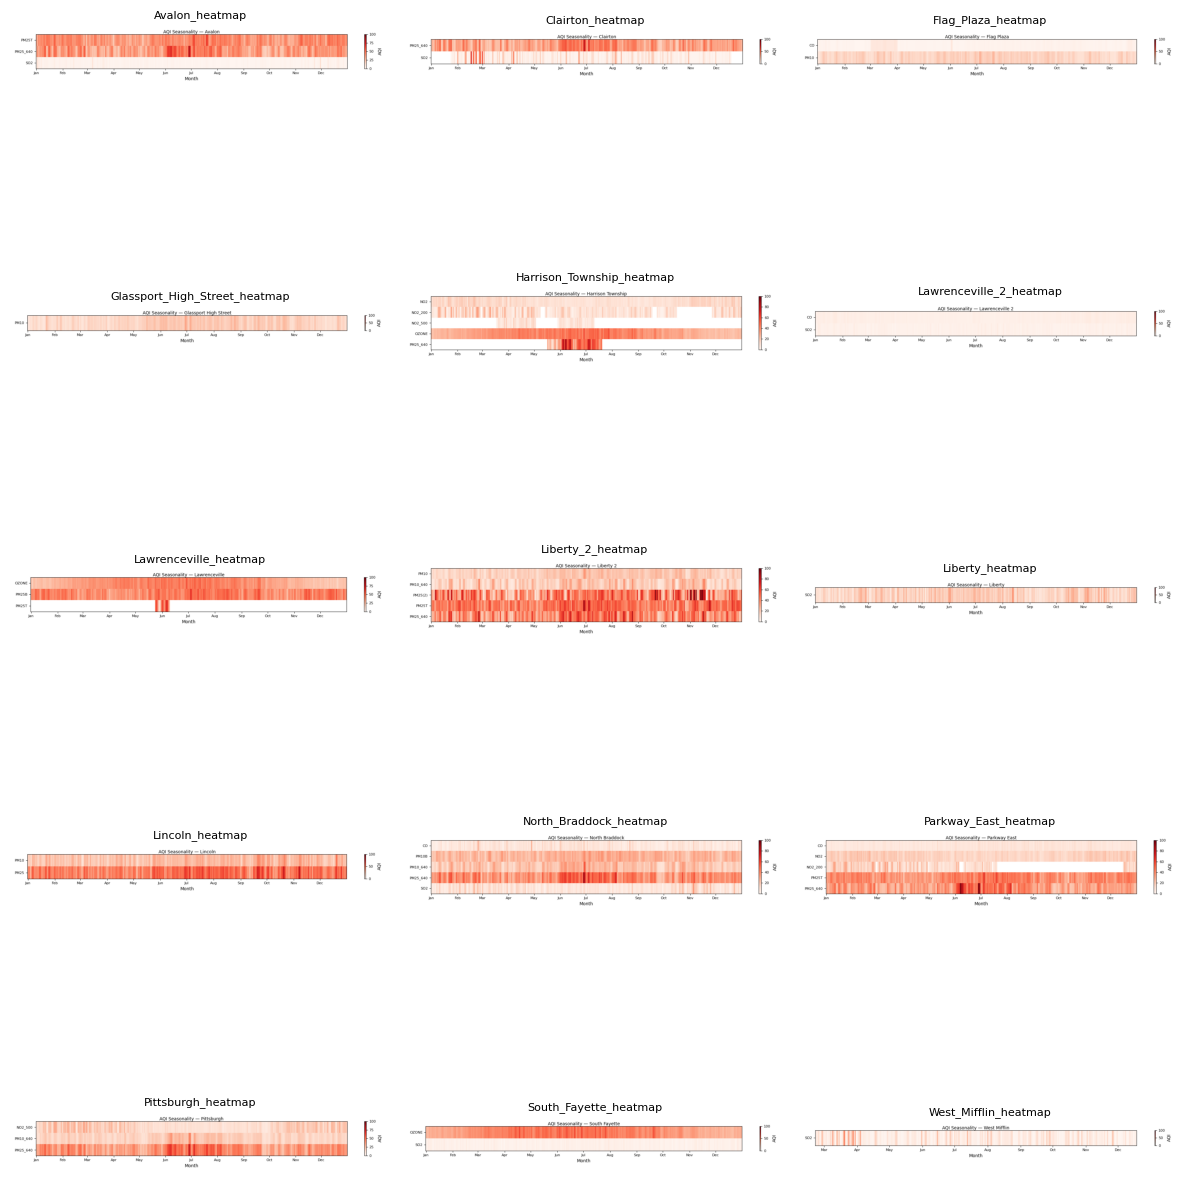

In [9]:
import os
import matplotlib.pyplot as plt

# 目录名称：替换为你的图像输出文件夹
output_dir = "site_heatmaps_fixed_100"  

# 列出所有 PNG 文件
files = sorted([f for f in os.listdir(output_dir) if f.endswith(".png")])

# 设置网格行列
cols = 3
rows = (len(files) + cols - 1) // cols

# 创建子图
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))

for ax, filename in zip(axes.flatten(), files):
    img = plt.imread(os.path.join(output_dir, filename))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(filename.replace(".png", ""), fontsize=8)

# 关闭多余的子图
for ax in axes.flatten()[len(files):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Here is some further research in details.

# Seasonal Drivers Behind Pittsburgh’s Summer Air Pollution

Pittsburgh’s severe summer air quality issues (June–August) are the result of **combined effects of industrial emissions and climate conditions**, rather than a single cause.



---



# 1. Industrial Emissions

- **Clairton Coke Works**, owned by U.S. Steel, is the largest coke plant in North America and a significant PM₂.₅ and toxic pollutant source in the region 
- It has repeatedly been flagged as one of Allegheny County’s top toxic polluters, and violations have led to fines and enforcement actions  
- Studies indicate that inversions intensify the effect of local industrial emission sources like Clairton, trapping pollutants near the ground 



---



# 2. Climatic Amplifiers

- Summer months feature frequent **surface-temperature inversions**, where warm air layers trap pollutants beneath—common during calm, hot weather 
- Pittsburgh’s unique topography (basins and hills) worsens this effect, enabling **urban heat islands** that boost local temperature and ozone formation 
- One study highlighted that inversions amplify PM₂.₅ concentrations more dramatically in summer than winter 



---



# 3. Secondary/Sporadic Sources

- **Wildfire smoke** from distant fires can travel into Pittsburgh during summer, compounding local industrial pollution and weather-driven smog heatwaves
- Increased construction and diesel traffic during summer months add to background PM₂.₅ levels 



---



# Conclusion & Summary

| Factor       | Effect on Summer AQI   |
|--------------|-------------------------|
| **Industrial Emissions** | Persistent high PM₂.₅ from large plants like Clairton |
| **Temperature Inversions & UHI** | Trap pollutants and accelerate ozone formation |
| **Wildfire Smoke + Traffic** | Additions to PM₂.₅ and smog, particularly in summer |

**Verdict:** Summer air quality issues in the Pittsburgh region are **driven by the synergy** between high industrial emissions and **weather patterns that trap and enhance pollutants**—not one single cause, which has a little bit different with our initial conclusion.



---



## References

1. Clairton Coke Works: Allegheny County’s largest coke plant and major emissions source   
2. Summer inversions trap PM₂.₅ and other pollutants in basins like Mon Valley   
3. Inversions and urban heat island effects intensify smog formation   
4. Documented impact synergy: industrial emissions worsen under inversion events  
5. Wildfire smoke adds episodic PM₂.₅ spikes during summer 



---


